# Time-Domain Gerchberg-Saxton: Carrier-less Optical Phase Recovery

**Project simulator** (Jalali Lab, *Dispersion-assisted Optical Phase Recovery*). The goal of
carrier-less coherent reception: recover the optical phase $\phi(t)$ from **intensity measurements
alone** — no local oscillator, no coherent mixing. The trick is **dispersion diversity**: send the
pulse through two different amounts of fibre dispersion $D_1, D_2$, detect the two intensities
$I_1=|\,\mathcal D_{D_1}E\,|^2$ and $I_2=|\,\mathcal D_{D_2}E\,|^2$, and let a time-domain
Gerchberg-Saxton loop find the one phase consistent with both.

$$\boxed{\;I_1,\ I_2\ \xrightarrow{\text{TD-GS}}\ \phi(t)\;}$$

This is the time-domain twin of classical GS, where the **dispersion operator plays the role of the
Fourier transform** between the two measurement planes. Built on the repo's `gs_core.py`.

Tasks covered: (3) chirped-Gaussian generation, (4) the TD-GS simulator, (5) recovery on
comms-style data — plus the dispersion-diversity condition that makes or breaks it.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import gs_core as gs

def align_phase(phi_rec, phi_true, weight):
    # GS recovers phase up to a global offset and a conjugate (twin) ambiguity
    best = None
    for sign in (+1, -1):
        d = phi_true - sign * phi_rec
        offset = np.angle(np.sum(weight * np.exp(1j * d)))
        aligned = sign * phi_rec + offset
        err = np.sqrt(np.sum(weight * np.angle(np.exp(1j*(phi_true-aligned)))**2) / np.sum(weight))
        if best is None or err < best[0]:
            best = (err, aligned)
    return best[0], best[1]

print("gs_core loaded; dispersion H[k] = exp(i pi D nu^2)")

gs_core loaded; dispersion H[k] = exp(i pi D nu^2)


## §1 Task 3 — a Gaussian pulse with engineered phase (chirp)

A transform-limited Gaussian carries no phase information; a **chirped** Gaussian has a quadratic
phase $\phi(t)=C\,t^2$ (instantaneous frequency sweeps linearly). This is the simplest "engineered
phase" test pulse.

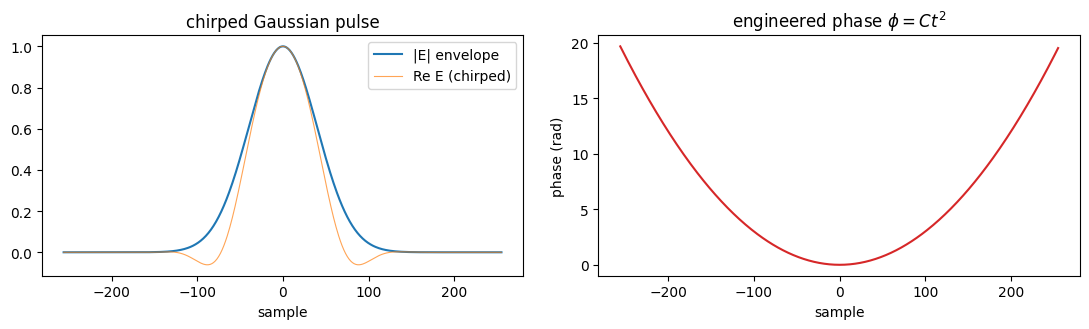

In [2]:
N = 512
n = np.arange(N) - N/2
envelope = np.exp(-(n/40)**2 / 2)
chirp = 3e-4
phi_chirp = chirp * n**2
E_chirp = envelope * np.exp(1j * phi_chirp)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(n, envelope, label="|E| envelope")
ax[0].plot(n, np.real(E_chirp), lw=0.8, alpha=0.7, label="Re E (chirped)")
ax[0].set_title("chirped Gaussian pulse"); ax[0].legend(); ax[0].set_xlabel("sample")
ax[1].plot(n, phi_chirp, "C3"); ax[1].set_title(r"engineered phase $\phi=C t^2$")
ax[1].set_xlabel("sample"); ax[1].set_ylabel("phase (rad)")
plt.tight_layout(); plt.show()

**An honest caveat (and a real lesson):** a *pure* chirped Gaussian is a poor TD-GS target. A
Gaussian disperses into another Gaussian, so $I_1$ and $I_2$ stay nearly identical (correlation
$>0.99$) no matter how large $D$ is — there is no diversity to exploit, and GS stagnates. Phase
retrieval needs a signal whose **dispersed intensity actually changes shape** — i.e. rich spectral
content. That is exactly what real communication signals provide.

In [3]:
for D in (-5000.0, -9000.0):
    I1c = np.abs(gs.disperse(E_chirp, D))**2
    I2c = np.abs(gs.disperse(E_chirp, D*1.15))**2
    print(f"chirped Gaussian, |D|={abs(D):.0f}: corr(I1,I2) = "
          f"{np.corrcoef(I1c, I2c)[0,1]:.4f}  (too high -> degenerate)")

chirped Gaussian, |D|=5000: corr(I1,I2) = 0.9991  (too high -> degenerate)
chirped Gaussian, |D|=9000: corr(I1,I2) = 0.9982  (too high -> degenerate)


## §2 The measurement: a smooth-phase comms signal through two dispersions

The canonical TD-GS signal (paper Fig. 5) is a **constant-envelope** field $E=e^{i\phi(t)}$ with a
bandlimited random phase — the structure of a phase-modulated carrier-less link. Disperse it by
$D_1=-5000$ and $D_2=-5750$ (ratio 1.15, matching the paper's DCF fibre) and detect the two
intensities.

corr(I1, I2) = 0.3697  (decorrelated -> good diversity)


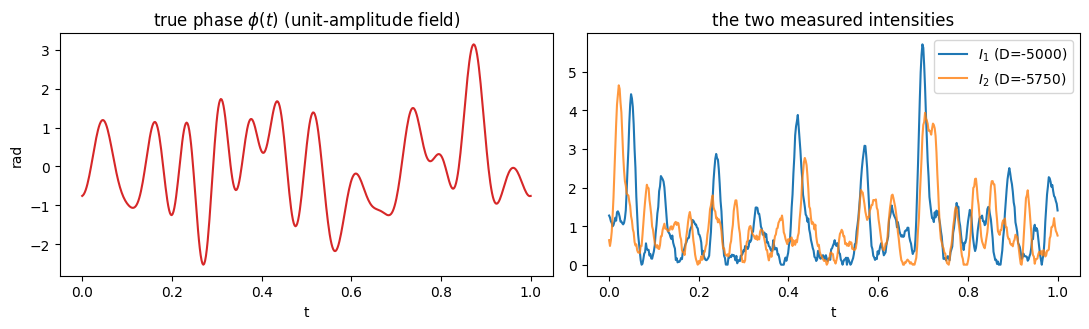

In [4]:
data = gs.make_qpsk_measurements(n_symbols=64, sps=8, D1=-5000.0, D2=-5750.0, snr_db=25.0)
I1, I2, phi_true, t = data["I1"], data["I2"], data["phi_true"], data["t"]
print(f"corr(I1, I2) = {np.corrcoef(I1, I2)[0,1]:.4f}  (decorrelated -> good diversity)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(t, phi_true, "C3"); ax[0].set_title(r"true phase $\phi(t)$ (unit-amplitude field)")
ax[0].set_xlabel("t"); ax[0].set_ylabel("rad")
ax[1].plot(t, I1, label="$I_1$ (D=-5000)"); ax[1].plot(t, I2, label="$I_2$ (D=-5750)", alpha=0.8)
ax[1].set_title("the two measured intensities"); ax[1].legend(); ax[1].set_xlabel("t")
plt.tight_layout(); plt.show()

## §3 Task 4 — the TD-GS loop recovers the phase

Each iteration is two alternating projections: disperse to the $D_1$ plane and force $|E|=\sqrt{I_1}$,
return; disperse to the $D_2$ plane and force $|E|=\sqrt{I_2}$, return. With constant-envelope
signals we also impose $|E(t)|=1$ each pass. The estimate converges to the field consistent with
*both* intensities — recovering $\phi(t)$ up to a global offset.

recovered phase RMS error = 0.0610 rad over [-pi, pi]


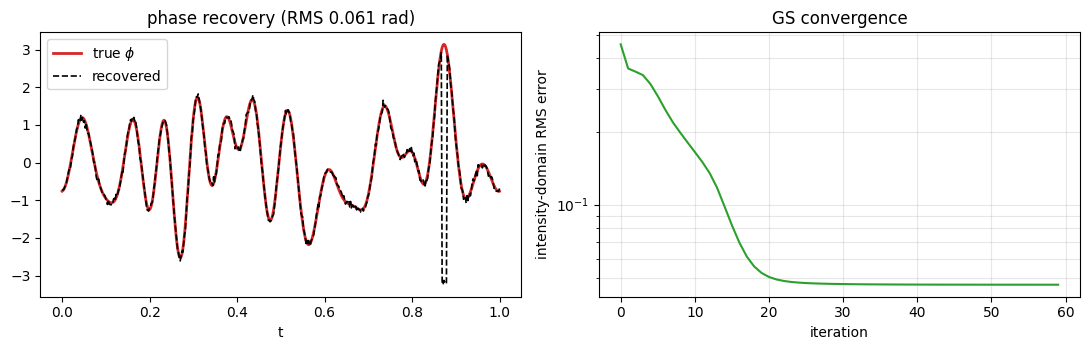

In [5]:
phi_rec, errors = gs.retrieve_phase(I1, I2, data["D1"], data["D2"],
                                    n_iter=60, unit_amplitude=True)
rms, phi_aligned = align_phase(phi_rec, phi_true, np.ones_like(phi_rec))
print(f"recovered phase RMS error = {rms:.4f} rad over [-pi, pi]")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(t, phi_true, "C3", lw=2, label="true $\\phi$")
ax[0].plot(t, phi_aligned, "k--", lw=1.2, label="recovered")
ax[0].set_title(f"phase recovery (RMS {rms:.3f} rad)"); ax[0].legend(); ax[0].set_xlabel("t")
ax[1].semilogy(errors, "C2")
ax[1].set_title("GS convergence"); ax[1].set_xlabel("iteration")
ax[1].set_ylabel("intensity-domain RMS error"); ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## §4 Why $|D|\gtrsim 5000$: dispersion *is* the diversity

The whole method hinges on $I_1\neq I_2$. Too little dispersion and the two intensities are nearly
the same ($\mathrm{corr}\to1$) — no information, GS stalls. Increase $|D|$ and they decorrelate, the
phase becomes recoverable. Past a point, *too much* dispersion smears the signal and the error
creeps back up. Sweep it: there is a clear working window around the paper's $|D|\approx5000$.

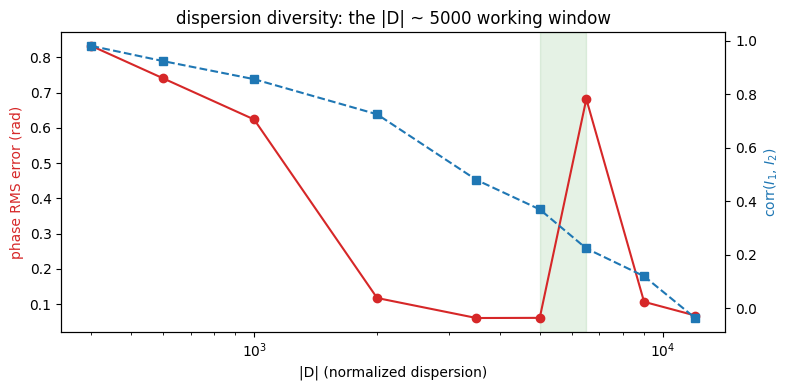

  |D|=  400: corr=0.981  phase err=0.832 rad  (low diversity)
  |D|=  600: corr=0.924  phase err=0.740 rad  (low diversity)
  |D|= 1000: corr=0.857  phase err=0.624 rad
  |D|= 2000: corr=0.725  phase err=0.117 rad
  |D|= 3500: corr=0.480  phase err=0.060 rad  <- working window
  |D|= 5000: corr=0.370  phase err=0.061 rad  <- working window
  |D|= 6500: corr=0.223  phase err=0.682 rad
  |D|= 9000: corr=0.120  phase err=0.106 rad
  |D|=12000: corr=-0.037  phase err=0.068 rad  <- working window


In [6]:
Dmags = [400, 600, 1000, 2000, 3500, 5000, 6500, 9000, 12000]
corrs, perrs = [], []
for Dm in Dmags:
    d = gs.make_qpsk_measurements(n_symbols=64, sps=8, D1=-float(Dm), D2=-float(Dm)*1.15)
    pr, _ = gs.retrieve_phase(d["I1"], d["I2"], d["D1"], d["D2"], n_iter=60, unit_amplitude=True)
    pe, _ = align_phase(pr, d["phi_true"], np.ones_like(pr))
    corrs.append(np.corrcoef(d["I1"], d["I2"])[0, 1]); perrs.append(pe)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.semilogx(Dmags, perrs, "o-", color="C3", label="phase RMS error")
ax1.set_xlabel("|D| (normalized dispersion)"); ax1.set_ylabel("phase RMS error (rad)", color="C3")
ax1.axvspan(5000, 6500, alpha=0.1, color="green")
ax2 = ax1.twinx()
ax2.semilogx(Dmags, corrs, "s--", color="C0", label="corr($I_1,I_2$)")
ax2.set_ylabel("corr($I_1$, $I_2$)", color="C0")
ax1.set_title("dispersion diversity: the |D| ~ 5000 working window")
fig.tight_layout(); plt.show()
for Dm, c, e in zip(Dmags, corrs, perrs):
    flag = "  <- working window" if e < 0.1 else ("  (low diversity)" if c > 0.9 else "")
    print(f"  |D|={Dm:>5}: corr={c:.3f}  phase err={e:.3f} rad{flag}")

## §5 What this is, and where it goes

- **Carrier-less reception, demonstrated.** Two square-law (intensity) detectors and a known pair of
  fibre dispersions recover the full optical phase — no local oscillator, no coherent front end.
  That is the Project's thesis, working end-to-end above.
- **Dispersion is the transform.** TD-GS is classical Gerchberg-Saxton with the dispersion operator
  $\mathcal D_D=\mathcal F^{-1}e^{i\pi D\nu^2}\mathcal F$ in place of the Fourier transform; $I_1,I_2$
  are the intensities in two "planes" the dispersion maps between. The $|D|\approx5000$ window is the
  diversity condition — the direct analog of needing well-separated measurement planes in optics.
- **Next (Task 5).** Swap the synthetic `make_qpsk_measurements` for the lab's optical-comms capture:
  feed measured $I_1, I_2$ straight into `retrieve_phase`. The FNO in `gs_fno.py` is the learned
  accelerator — same physics, spectral-convolution layers replacing the iteration.
- **Honest limits.** Pure chirped Gaussians are degenerate (§1); constant-envelope phase signals with
  $|D|$ in the working window are the regime where TD-GS is reliable. Knowing which signals it can and
  cannot handle is the engineering, not a footnote.

Uses `gs_core.py` (`disperse`/`retrieve_phase`/`make_qpsk_measurements`); benchmarked in
`scripts/smoke_tdgs_demo.py`. This notebook is the simulator deliverable for the Jalali-Lab project
(repo: github.com/ColinsCoding/Dispersion-Assisted-GS-Phase-Recovery).

import sympy as sp

x = sp.symbols('x')

sp.dsolve(
    sp.Eq(sp.diff(sp.Function('y')(x), x, 2)
          + sp.Function('y')(x), 0)
)

In [7]:
import sympy as sp

x = sp.symbols('x')

sp.dsolve(
    sp.Eq(sp.diff(sp.Function('y')(x), x, 2)
          + sp.Function('y')(x), 0)
)

Eq(y(x), C1*sin(x) + C2*cos(x))

In [8]:
import sympy as sp
import pandas as pd

x = sp.symbols('x')

f = x**3 - 2*x + 1
fp = sp.diff(f, x)

rows = []

for val in range(-5, 6):
    rows.append({
        "x": val,
        "f(x)": float(f.subs(x, val)),
        "f'(x)": float(fp.subs(x, val))
    })

df = pd.DataFrame(rows)

print(df)

    x   f(x)  f'(x)
0  -5 -114.0   73.0
1  -4  -55.0   46.0
2  -3  -20.0   25.0
3  -2   -3.0   10.0
4  -1    2.0    1.0
5   0    1.0   -2.0
6   1    0.0    1.0
7   2    5.0   10.0
8   3   22.0   25.0
9   4   57.0   46.0
10  5  116.0   73.0


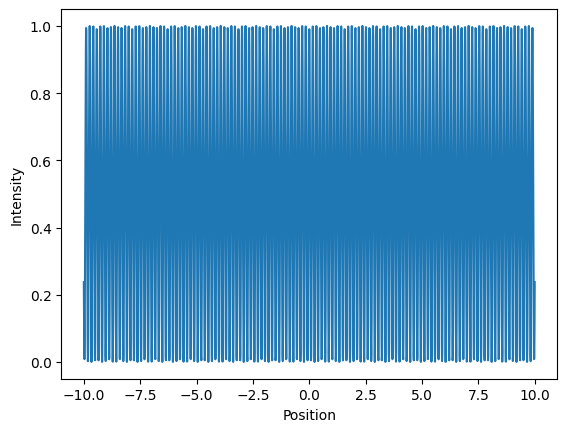

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 2000)

k = 10
d = 2

I = np.cos(k*d*x)**2

plt.plot(x, I)
plt.xlabel("Position")
plt.ylabel("Intensity")
plt.show()

In [10]:
import torch

x = torch.linspace(-10, 10, 2000)

I = torch.cos(2*x)**2

print(I[:10])

tensor([0.1665, 0.1817, 0.1974, 0.2136, 0.2302, 0.2472, 0.2647, 0.2825, 0.3007,
        0.3192])


In [11]:
import sympy as sp

r, Fx, Fy, Fz = sp.symbols('r Fx Fy Fz')

F = sp.Matrix([Fx, Fy, Fz])
R = sp.Matrix([r, 0, 0])

torque = R.cross(F)

print(torque)

Matrix([[0], [-Fz*r], [Fy*r]])


In [ ]:
import sympy as sp
import pandas as pd

# Symbols
x, y, n = sp.symbols("x y n")

# Functions / expressions
f = x**2 + 3*x + 2
g = sp.exp(x)
h = sp.sin(x) / x

expressions = {
    "polynomial": f,
    "exponential": g,
    "trig_fraction": h,
}

rows = []

for name, expr in expressions.items():
    rows.append({
        "name": name,
        "math": expr,
        "latex": sp.latex(expr),
        "derivative": sp.diff(expr, x),
        "integral": sp.integrate(expr, x),
        "value_at_2": expr.subs(x, 2),
    })

df = pd.DataFrame(rows)
df

,name,math,latex,derivative,integral,value_at_2
0,polynomial,x**2 + 3*x + 2,x^{2} + 3 x + 2,2*x + 3,x**3/3 + 3*x**2/2 + 2*x,12
1,exponential,exp(x),e^{x},exp(x),exp(x),exp(2)
2,trig_fraction,sin(x)/x,\frac{\sin{\left(x \right)}}{x},cos(x)/x - sin(x)/x**2,Si(x),sin(2)/2


: 